In [1]:
# CELL 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
import pandas as pd
import io
from google.colab import files

# Prompt to select and upload the file from your computer
uploaded = files.upload()

# Automatically grabs the uploaded file name
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Shape (rows, columns):", df.shape)
print(df.columns.tolist())
df.head()

Saving Jun-09-2026_Sep-07-2026_Content_Publish time_Summary_1079852851618101.csv to Jun-09-2026_Sep-07-2026_Content_Publish time_Summary_1079852851618101 (1).csv
Shape (rows, columns): (18, 20)
['Post ID', 'Page ID', 'Page name', 'Title', 'Duration (sec)', 'Publish time', 'Permalink', 'Post type', 'Data comment', 'Date', 'Comments', 'Distribution', 'Impressions', 'Interactions', 'Net follows', 'Reactions', 'Saves', 'Shares', 'Viewers', 'Views']


,Post ID,Page ID,Page name,Title,Duration (sec),Publish time,Permalink,Post type,Data comment,Date,Comments,Distribution,Impressions,Interactions,Net follows,Reactions,Saves,Shares,Viewers,Views
0,122093653917390912,61591727361372,The Humans of BRACU,NaN,0,06/29/2026 20:22,https://www.facebook.com/photo.php?fbid=122093...,Photo,NaN,Lifetime,0,--,16,18,0,18,0,0,13,23
1,122126301783390912,61591727361372,The Humans of BRACU,"An Academic, A Musician and An Architect. \n\n...",0,09/07/2026 06:00,https://www.facebook.com/permalink.php?story_f...,Photo,NaN,Lifetime,1,--,342,25,0,23,0,4,338,574
2,122126039853390912,61591727361372,The Humans of BRACU,"Learning, Growing, and Finding My Path\n\nWhen...",0,09/06/2026 06:26,https://www.facebook.com/permalink.php?story_f...,Photo,NaN,Lifetime,2,--,1304,51,2,46,2,1,1280,2348
3,122125516911390912,61591727361372,The Humans of BRACU,"Across Borders, Into Her Own Story 🌍\n\nToday ...",0,09/04/2026 06:58,https://www.facebook.com/permalink.php?story_f...,Photo,NaN,Lifetime,76,--,9252,201,63,430,14,14,8662,20046
4,122125293123390912,61591727361372,The Humans of BRACU,“ Don’t be in such a hurry to have everything ...,0,09/03/2026 06:45,https://www.facebook.com/permalink.php?story_f...,Photo,NaN,Lifetime,68,--,18916,531,104,873,30,75,16976,40361


In [4]:
# CELL 3: Clean the data
df["Publish time"] = pd.to_datetime(df["Publish time"])
df["day_of_week"] = df["Publish time"].dt.day_name()
df["hour"] = df["Publish time"].dt.hour

# Drop the 2 posts with no Title (page launch/test posts, not real content)
df_content = df[df["Title"].notna()].copy()

print("Full dataset:", df.shape[0], "posts")
print("Content-only dataset (real story posts):", df_content.shape[0], "posts")

Full dataset: 18 posts
Content-only dataset (real story posts): 16 posts


In [5]:
# CELL 4: Create new columns we need for analysis
df_content["engagement_rate"] = df_content["Interactions"] / df_content["Impressions"]
df_content["title_char_count"] = df_content["Title"].str.len()
df_content["title_word_count"] = df_content["Title"].str.split().str.len()

df_content[["Title", "Views", "engagement_rate", "title_word_count"]].sort_values(
    "Views", ascending=False
).head(10)

,Title,Views,engagement_rate,title_word_count
7,From 2.26 CGPA to a journey that I’ll always ...,131418,0.017067,351
16,"RocknRoll , Business Analytics and a whole lot...",76257,0.010661,292
4,“ Don’t be in such a hurry to have everything ...,40361,0.028071,498
15,"Bullied, Broken , and a Deck of Cards. \n\nFor...",27164,0.007755,373
12,A Journey of Purpose: A Conversation with Dr. ...,23270,0.013946,1080
5,When you look at the massive billboards toweri...,22622,0.013223,721
6,"""Sometimes, the path that makes the least sens...",20405,0.015688,798
3,"Across Borders, Into Her Own Story 🌍\n\nToday ...",20046,0.021725,327
9,"Resilience, Hustle and Independence.\n\nIn Cla...",13502,0.011168,364
13,"For this edition of The Humans of BRACU, we br...",12732,0.013282,520


In [6]:
# CELL 5: Basic summary stats
print("Total Impressions:", df_content["Impressions"].sum())
print("Total Views:", df_content["Views"].sum())
print("Total Interactions:", df_content["Interactions"].sum())
print("Total Net Follows (from posts):", df_content["Net follows"].sum())
print("\nAverage engagement rate: {:.2%}".format(df_content["engagement_rate"].mean()))

df_content[["Impressions", "Views", "Interactions", "Net follows"]].describe()

Total Impressions: 223659
Total Views: 434236
Total Interactions: 3512
Total Net Follows (from posts): 962

Average engagement rate: 2.06%


,Impressions,Views,Interactions,Net follows
count,16.000000,16.000000,16.000000,16.000000
mean,13978.687500,27139.750000,219.500000,60.125000
std,17446.330455,33032.106667,284.696329,82.709834
min,342.000000,574.000000,25.000000,0.000000
25%,5198.000000,11165.500000,74.000000,17.750000
50%,7622.000000,16774.000000,103.500000,25.000000
75%,15043.250000,24243.500000,201.500000,67.750000
max,67031.000000,131418.000000,1144.000000,316.000000


In [7]:
# CELL 6: What correlates most with follower growth?
metrics = ["Comments", "Impressions", "Interactions", "Net follows",
           "Reactions", "Saves", "Shares", "Viewers", "Views"]

correlation_with_follows = df_content[metrics].corr()["Net follows"].sort_values(ascending=False)
print(correlation_with_follows)

Net follows     1.000000
Views           0.985500
Impressions     0.983865
Viewers         0.982811
Interactions    0.971292
Reactions       0.908241
Saves           0.903602
Shares          0.826843
Comments        0.665041
Name: Net follows, dtype: float64


                     Views  title_char_count  title_word_count
Views             1.000000         -0.280642         -0.254305
title_char_count -0.280642          1.000000          0.996162
title_word_count -0.254305          0.996162          1.000000


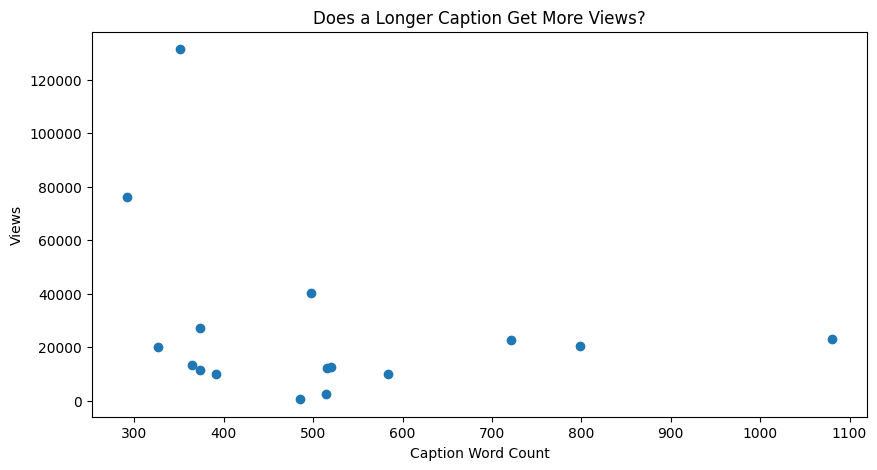

In [8]:
# CELL 7: Does caption length matter? (spoiler: not much)
correlation_with_views = df_content[["Views", "title_char_count", "title_word_count"]].corr()
print(correlation_with_views)

plt.scatter(df_content["title_word_count"], df_content["Views"])
plt.xlabel("Caption Word Count")
plt.ylabel("Views")
plt.title("Does a Longer Caption Get More Views?")
plt.show()

                                 mean  count
hook_style                                  
Numeric/Vivid Contrast   56889.666667      3
Faculty Curiosity        33367.000000      3
Quote-Led                30383.000000      2
Curiosity/Imagery        22622.000000      1
Place/Travel             14933.000000      2
Vulnerability Statement  12732.000000      1
Generic Abstract Noun     9370.000000      4


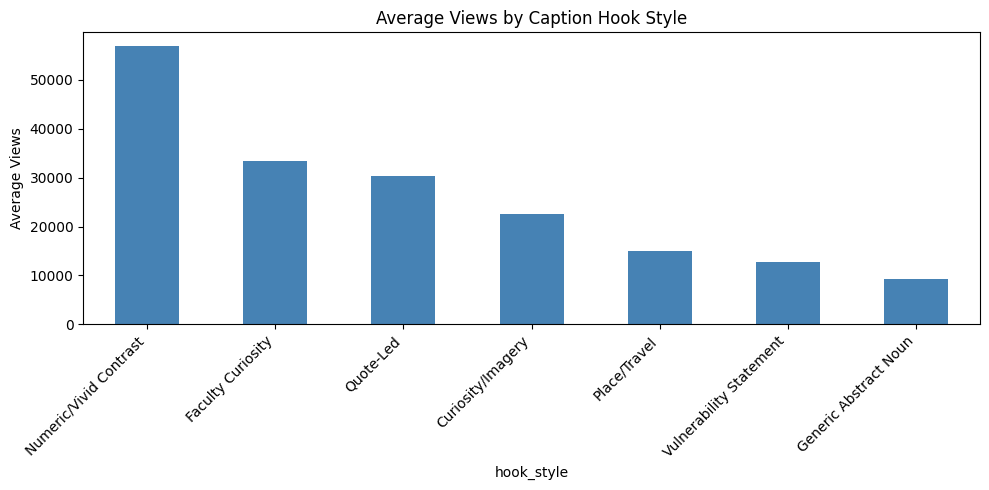

In [10]:
# CELL 9: Compare average Views by hook style -- THE MAIN FINDING
hook_summary = (
    df_content.groupby("hook_style")["Views"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)
print(hook_summary)

hook_summary["mean"].plot(kind="bar", color="steelblue")
plt.ylabel("Average Views")
plt.title("Average Views by Caption Hook Style")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

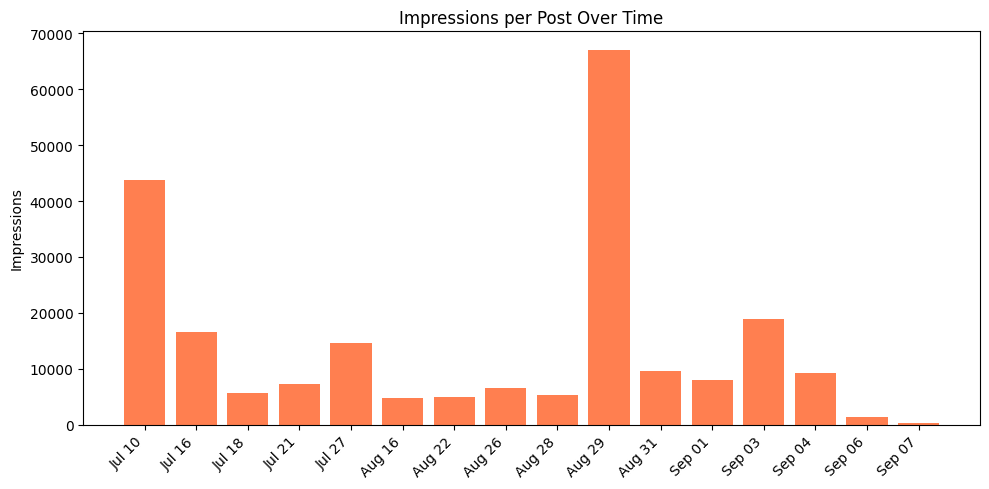

In [11]:
# CELL 10: Reach over time -- shows the spike and the recent decline
df_sorted = df_content.sort_values("Publish time")

plt.bar(df_sorted["Publish time"].dt.strftime("%b %d"), df_sorted["Impressions"], color="coral")
plt.ylabel("Impressions")
plt.title("Impressions per Post Over Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

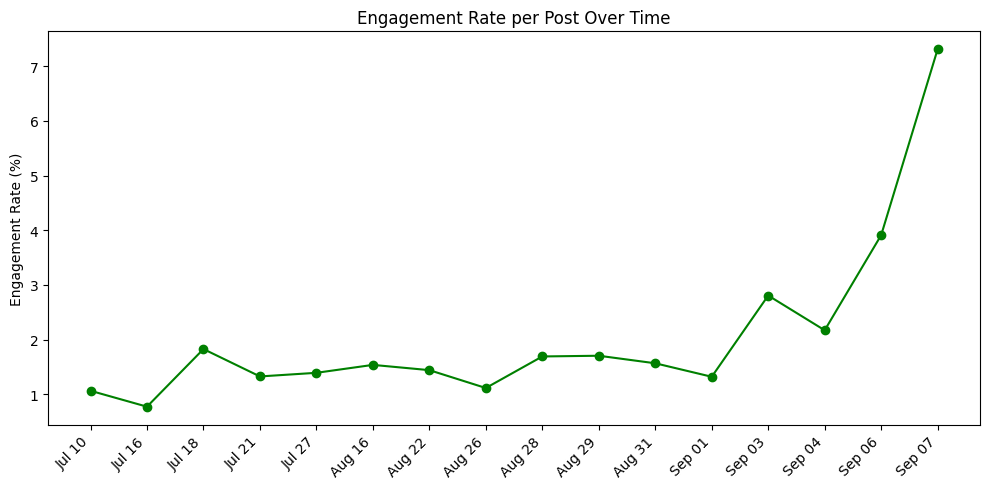

In [12]:
# CELL 11: Engagement rate over time
plt.plot(df_sorted["Publish time"].dt.strftime("%b %d"), df_sorted["engagement_rate"] * 100,
         marker="o", color="green")
plt.ylabel("Engagement Rate (%)")
plt.title("Engagement Rate per Post Over Time")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
# CELL 12: Day-of-week and hour patterns (use with caution -- small sample)
print("Average interactions by day of week:")
print(df_content.groupby("day_of_week")["Interactions"].agg(["mean", "count"]))

print("\nAverage interactions by posting hour:")
print(df_content.groupby("hour")["Interactions"].agg(["mean", "count"]))

Average interactions by day of week:
                   mean  count
day_of_week                   
Friday       252.333333      3
Monday       126.333333      3
Saturday     438.666667      3
Sunday        62.500000      2
Thursday     329.500000      2
Tuesday      101.000000      2
Wednesday     74.000000      1

Average interactions by posting hour:
            mean  count
hour                   
5      70.000000      1
6     276.111111      9
7     112.500000      2
8     183.000000      4


In [14]:
# CELL 13: Print the final takeaway
top_hook = hook_summary["mean"].idxmax()
bottom_hook = hook_summary["mean"].idxmin()

print(f"Best-performing hook style: {top_hook} "
      f"({hook_summary.loc[top_hook, 'mean']:.0f} avg views)")
print(f"Weakest-performing hook style: {bottom_hook} "
      f"({hook_summary.loc[bottom_hook, 'mean']:.0f} avg views)")
print(f"\nCorrelation between caption length and Views: "
      f"{df_content['title_word_count'].corr(df_content['Views']):.2f} (weak/near zero)")
print(f"Correlation between Interactions and Net Follows: "
      f"{df_content['Interactions'].corr(df_content['Net follows']):.2f} (strong)")

Best-performing hook style: Numeric/Vivid Contrast (56890 avg views)
Weakest-performing hook style: Generic Abstract Noun (9370 avg views)

Correlation between caption length and Views: -0.25 (weak/near zero)
Correlation between Interactions and Net Follows: 0.97 (strong)



Analyzing social media campaign data requires converting raw metrics into actionable storytelling strategies that drive organic growth and audience retention.

**The Business Problem**
Content creators often struggle to identify why certain posts achieve viral reach while others with high production value underperform. This analysis evaluates performance patterns across "The Humans of BRACU" campaign to uncover narrative triggers that maximize engagement, prevent audience alienation, and drive sustainable follower acquisition.

**The Data**

* **Source & Scope**: Meta Content Performance dataset covering campaign analytics from June 09, 2026, to September 07, 2026.


* **Dimensions**: Dataset contains 18 total rows and 20 performance columns.


* **Key Variables**: Views, Impressions, Net Follows, Interactions (Reactions, Shares, Comments), and Post Title transcript text.



**Methodology**

* **Tools**: Executed in Python using `pandas` for data structuring and exploratory statistics, alongside standard visualization libraries.


* **Data Preparation**: Parsed datetime objects, filtered non-content metadata rows, categorized qualitative story themes, and calculated metric ratios to isolate follower conversion efficiency.



**Key Findings & Insights**

* **Vulnerability Drives Virality**: Stories anchored in raw personal struggle—such as Abidur Rahman Bhuiyan's comeback from a 2.26 CGPA—generated peak performance (131,418 views, 316 net follows) due to high student empathy.


* **Subverting Stereotypes Converts**: Unconventional faculty spotlights (e.g., Raad Ryasaat Khan's "paid to yap" narrative) subverted academic norms, driving 76,257 views and 182 net follows.


* **The "Success Alienation" Trap**: Stories heavily emphasizing commercial accolades or polish (e.g., Fabiha Bushra with 13,502 views) underperformed because they felt like corporate CVs lacking central conflict.


* **Demographic Resonance**: With 55.1% of viewers aged 18–24 and 93.8% located in Dhaka, content strongly favored hyper-local, relatable academic growth arcs over external brand achievements.



**Recommendations**

* **Lead with Setbacks**: Structure narratives around a core obstacle or failure before revealing achievements to avoid alienating the audience.


* **Humanize Authority Figures**: Focus on informal, creative side-passions when featuring faculty members to increase shareability.


* **Prioritize Mentorship Narratives**: Emphasize human connections and emotional growth over exhaustive lists of resume accomplishments.



**Limitations & Challenges**
This analysis was constrained by a limited sample size of 18 posts published within a 90-day evaluation window, restricting broad longitudinal projections. Furthermore, qualitative coding of post titles introduces subjective sentiment classification, and underlying algorithmic updates on the distribution platform could create unmeasured variance in organic reach.